# 01 Data Loading and Understanding

This notebook builds a daily weather plus PM2.5 dataset by:
- scraping weather values from the monthly HTML climate files
- aggregating hourly PM2.5 values into daily PM2.5
- merging both sources by date

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

BASE_DIR = Path.cwd()
AQI_DIR = BASE_DIR / "data" / "AQI"
HTML_DIR = BASE_DIR / "data" / "html_data"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

In [2]:
import sys
import subprocess

try:
    from bs4 import BeautifulSoup
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "beautifulsoup4"])
    from bs4 import BeautifulSoup


def parse_weather_html_files(html_root: Path) -> pd.DataFrame:
    rows = []

    for html_file in sorted(html_root.rglob("*.html")):
        year = html_file.parent.name
        month = html_file.stem.split("-")[0]

        soup = BeautifulSoup(html_file.read_text(encoding="utf-8", errors="ignore"), "html.parser")
        tables = soup.find_all("table")
        if len(tables) < 4:
            continue

        climate_table = tables[3]
        for tr in climate_table.find_all("tr")[1:]:
            cells = [cell.get_text(" ", strip=True) for cell in tr.find_all(["td", "th"])]
            if len(cells) < 15 or not cells[0].isdigit():
                continue

            day = int(cells[0])
            rows.append(
                {
                    "Date": f"{year}-{int(month):02d}-{day:02d}",
                    "Avg_Temperature": cells[1],
                    "Max_Temperature": cells[2],
                    "Min_Temperature": cells[3],
                    "Sea_Level_Pressure": cells[4],
                    "Humidity": cells[5],
                    "Rainfall_Snowmelt": cells[6],
                    "Visibility": cells[7],
                    "Wind_Speed": cells[8],
                    "Max_Sustained_Wind_Speed": cells[9],
                    "Max_Wind_Gust": cells[10],
                    "City": "Bangalore",
                    "weather_source_file": html_file.name,
                }
            )

    weather_df = pd.DataFrame(rows)
    weather_df["Date"] = pd.to_datetime(weather_df["Date"], errors="coerce")

    numeric_weather_cols = [
        "Avg_Temperature",
        "Max_Temperature",
        "Min_Temperature",
        "Sea_Level_Pressure",
        "Humidity",
        "Rainfall_Snowmelt",
        "Visibility",
        "Wind_Speed",
        "Max_Sustained_Wind_Speed",
        "Max_Wind_Gust",
    ]

    for col in numeric_weather_cols:
        weather_df[col] = pd.to_numeric(
            weather_df[col].replace({"-": np.nan, "": np.nan}),
            errors="coerce"
        )

    weather_df["Month"] = weather_df["Date"].dt.month
    weather_df["Year"] = weather_df["Date"].dt.year
    weather_df["Day"] = weather_df["Date"].dt.day
    weather_df["DayOfWeek"] = weather_df["Date"].dt.dayofweek
    weather_df["IsWeekend"] = weather_df["DayOfWeek"].isin([5, 6]).astype(int)
    weather_df["Season"] = weather_df["Month"].map({
        12: "Winter", 1: "Winter", 2: "Winter",
        3: "Summer", 4: "Summer", 5: "Summer",
        6: "Monsoon", 7: "Monsoon", 8: "Monsoon", 9: "Monsoon",
        10: "Post-Monsoon", 11: "Post-Monsoon"
    })

    return weather_df


def load_and_aggregate_pm25(aqi_root: Path) -> pd.DataFrame:
    frames = []

    for csv_file in sorted(aqi_root.glob("*.csv")):
        df = pd.read_csv(csv_file)
        df.columns = [col.strip() for col in df.columns]
        df["Date"] = pd.to_datetime(df["Date"].astype(str).str.strip(), errors="coerce")
        df["Time"] = df["Time"].astype(str).str.strip()
        df["PM2.5"] = pd.to_numeric(df["PM2.5"], errors="coerce")
        frames.append(df)

    aqi_df = pd.concat(frames, ignore_index=True)
    aqi_df = aqi_df.drop_duplicates(subset=["Date", "Time", "PM2.5"]).copy()

    daily_pm25 = (
        aqi_df.groupby("Date", as_index=False)
        .agg(
            Daily_PM25=("PM2.5", "mean"),
            PM25_Observation_Count=("PM2.5", lambda s: s.notna().sum()),
        )
    )

    return daily_pm25

In [3]:
weather_df = parse_weather_html_files(HTML_DIR)
print("Weather data shape:", weather_df.shape)
weather_df.head()

Weather data shape: (2191, 19)


,Date,Avg_Temperature,Max_Temperature,Min_Temperature,Sea_Level_Pressure,Humidity,Rainfall_Snowmelt,Visibility,Wind_Speed,Max_Sustained_Wind_Speed,Max_Wind_Gust,City,weather_source_file,Month,Year,Day,DayOfWeek,IsWeekend,Season
0,2013-01-01,23.4,30.3,19.0,NaN,59.0,0.0,6.3,4.3,5.4,NaN,Bangalore,1-2013.html,1,2013,1,1,0,Winter
1,2013-01-02,22.4,30.3,16.9,NaN,57.0,0.0,6.9,3.3,7.6,NaN,Bangalore,1-2013.html,1,2013,2,2,0,Winter
2,2013-01-03,24.0,31.8,16.9,NaN,51.0,0.0,6.9,2.8,5.4,NaN,Bangalore,1-2013.html,1,2013,3,3,0,Winter
3,2013-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bangalore,1-2013.html,1,2013,4,4,0,Winter
4,2013-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bangalore,1-2013.html,1,2013,5,5,1,Winter


In [4]:
daily_pm25_df = load_and_aggregate_pm25(AQI_DIR)
print("Daily PM2.5 data shape:", daily_pm25_df.shape)
daily_pm25_df.head()

Daily PM2.5 data shape: (432, 3)


,Date,Daily_PM25,PM25_Observation_Count
0,2013-01-01,279.156522,23
1,2013-01-02,332.239130,23
2,2013-01-03,38.846154,13
3,2013-01-04,46.416667,12
4,2013-01-05,92.391304,23


In [5]:
merged_df = weather_df.merge(daily_pm25_df, on="Date", how="inner").sort_values("Date").reset_index(drop=True)

print("Merged dataset shape:", merged_df.shape)
print("Date range:", merged_df["Date"].min(), "to", merged_df["Date"].max())
merged_df.head()

Merged dataset shape: (432, 21)
Date range: 2013-01-01 00:00:00 to 2015-12-12 00:00:00


,Date,Avg_Temperature,Max_Temperature,Min_Temperature,Sea_Level_Pressure,Humidity,Rainfall_Snowmelt,Visibility,Wind_Speed,Max_Sustained_Wind_Speed,Max_Wind_Gust,City,weather_source_file,Month,Year,Day,DayOfWeek,IsWeekend,Season,Daily_PM25,PM25_Observation_Count
0,2013-01-01,23.4,30.3,19.0,NaN,59.0,0.0,6.3,4.3,5.4,NaN,Bangalore,1-2013.html,1,2013,1,1,0,Winter,279.156522,23
1,2013-01-02,22.4,30.3,16.9,NaN,57.0,0.0,6.9,3.3,7.6,NaN,Bangalore,1-2013.html,1,2013,2,2,0,Winter,332.239130,23
2,2013-01-03,24.0,31.8,16.9,NaN,51.0,0.0,6.9,2.8,5.4,NaN,Bangalore,1-2013.html,1,2013,3,3,0,Winter,38.846154,13
3,2013-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bangalore,1-2013.html,1,2013,4,4,0,Winter,46.416667,12
4,2013-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bangalore,1-2013.html,1,2013,5,5,1,Winter,92.391304,23


In [6]:
print("Shape of data:", merged_df.shape)
print("\nData types:")
display(merged_df.dtypes.to_frame(name="dtype"))

Shape of data: (432, 21)

Data types:


,dtype
Date,datetime64[ns]
Avg_Temperature,float64
Max_Temperature,float64
Min_Temperature,float64
Sea_Level_Pressure,float64
Humidity,float64
Rainfall_Snowmelt,float64
Visibility,float64
Wind_Speed,float64
Max_Sustained_Wind_Speed,float64


In [7]:
null_summary = pd.DataFrame({
    "missing_count": merged_df.isna().sum(),
    "missing_percent": (merged_df.isna().sum() / len(merged_df) * 100).round(2)
}).sort_values("missing_count", ascending=False)

null_summary

,missing_count,missing_percent
Sea_Level_Pressure,432,100.00
Max_Wind_Gust,432,100.00
Rainfall_Snowmelt,220,50.93
Max_Sustained_Wind_Speed,218,50.46
Max_Temperature,216,50.00
Wind_Speed,216,50.00
Min_Temperature,216,50.00
Avg_Temperature,216,50.00
Humidity,216,50.00
Visibility,216,50.00


In [8]:
merged_df.describe(include="all").transpose()

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,432,NaN,NaN,NaN,2014-06-22 00:00:00,2013-01-01 00:00:00,2013-09-26 06:00:00,2014-06-21 12:00:00,2015-03-17 00:00:00,2015-12-12 00:00:00,NaN
Avg_Temperature,216.0,NaN,NaN,NaN,24.017593,20.1,22.6,23.6,24.975,29.9,2.136976
Max_Temperature,216.0,NaN,NaN,NaN,30.494444,23.8,28.6,30.0,31.6,37.6,2.697262
Min_Temperature,216.0,NaN,NaN,NaN,19.791204,14.4,18.8,20.0,20.9,24.6,2.095125
Sea_Level_Pressure,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Humidity,216.0,NaN,NaN,NaN,67.694444,26.0,58.75,71.0,77.0,93.0,13.420538
Rainfall_Snowmelt,212.0,NaN,NaN,NaN,3.33434,0.0,0.0,0.0,0.76,79.76,10.721222
Visibility,216.0,NaN,NaN,NaN,6.664352,4.0,6.3,6.9,6.9,8.2,0.517038
Wind_Speed,216.0,NaN,NaN,NaN,3.975463,0.0,2.2,3.7,5.6,12.4,2.210861
Max_Sustained_Wind_Speed,214.0,NaN,NaN,NaN,7.120561,3.5,5.4,7.6,9.4,22.2,3.159433


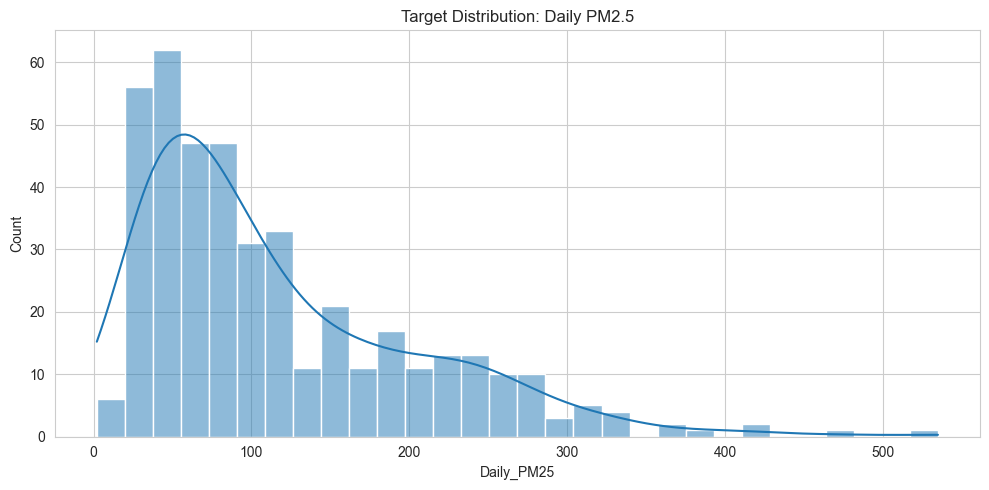

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(merged_df["Daily_PM25"].dropna(), bins=30, kde=True)
plt.title("Target Distribution: Daily PM2.5")
plt.tight_layout()
plt.show()

In [10]:
weather_df.to_csv(ARTIFACTS_DIR / "weather_daily_scraped.csv", index=False)
daily_pm25_df.to_csv(ARTIFACTS_DIR / "pm25_daily_aggregated.csv", index=False)
merged_df.to_csv(ARTIFACTS_DIR / "weather_pm25_merged.csv", index=False)

print("Saved merged PM2.5 dataset artifacts.")

Saved merged PM2.5 dataset artifacts.
